# Seminário Modelagem Economica Baseada em Agentes - SCX5013

## 1. Visão geral e motivação do modelo

### 1.1 Trabalhos abordados

Iremos abordar o modelo propostos nos trabalhos:

- `Economic forecasting with an agent-based model`, Poledna et al. (2023)
-  `Behavioural agent-based economic forecasting in Julia`, implementação open source na linguagem Julia por Aldo et al. (2025)

Utilizaremos a em Julia para explorar o modelo de maneira prática. 

### 1.2 Motivadores do modelo

- Realizar previsões macroeconômicas utilizando modelagem baseada em agentes
- Construir uma modelagem verossimilhante, calibrando o modelo de acordo com as estatísticas governamentais e executando a simulação com escala 1:1 da população do país

O modelo inicial de foi calibrado para a economia da Áustria, que é um pais pequeno e altamente integrado com a economia da Europa ($ \approx 9M$ habitantes  e $\approx 50\%  $ do PIB em importações/exportações).

### 1.3 Inicialização do modelo

Com os comandos abaixo inicializamos as condições de partida do modelo, parâmetros (fixos) e variáveis de estado (evoluem no tempo).

In [6]:
import BeforeIT as Bit
import Random
using Plots, StatsPlots, DataFrames, Statistics, LinearAlgebra


parameters = Bit.AUSTRIA2010Q1.parameters;
initial_conditions = Bit.AUSTRIA2010Q1.initial_conditions;
model = Bit.Model(parameters,initial_conditions);

### 1.4 Agentes do modelo

Podemos inspecionar as condições iniciais para nos informarmos sobre os agentes do modelo.

In [28]:
p = model.prop

agent_table = DataFrame(
        "Agent type"        => ["Trabalhadores ativos (empregados e desempregados)",
                                "Trabalhadores inativos",
                                "Empresas (e donos de empresas)",
                                "Governos (central e locais)",
                                "Consumidores externos",
                                "Empresas estrangeiras (importadoras)",
                                "Banco central (Taxa Básica)",
                                "Banco comercial representativo (Taxa de Juros)"],
        "Count"             => [p.H_act, p.H_inact, p.I, p.J, p.L, p.G, round(100*model.cb.r_bar; digits = 2), round(100*model.bank.r;digits =2)],
    )

Row,Agent type,Count
,String,Float64
1,Trabalhadores ativos (empregados e desempregados),4743.0
2,Trabalhadores inativos,4130.0
3,Empresas (e donos de empresas),624.0
4,Governos (central e locais),156.0
5,Consumidores externos,312.0
6,Empresas estrangeiras (importadoras),62.0
7,Banco central (Taxa Básica),0.16
8,Banco comercial representativo (Taxa de Juros),2.84


### 1.5 Evolução temporal 

Cada etapa temporal do modelo equivale a um `trimestre`. As etapas-chave que levam o modelo de $t$ para $t+1$ são:

1. Formação de expectativas coletivas - regra AR(1) 
2. Execução dos choques exógenos - regra AR(1)
3. Execução dos mercados de crédito e trabalho
4. Execução dos mercados de bens  
4. Atualização da contabilidade

Abaixo, vamos veremos a progressão de algumas dessas varíaveis a partir de uma execução real do modelo. 

In [ ]:
T_horizon = 20 # 20 trimestres / 5 anos
Random.seed!(123)
Bit.run!(model, T_horizon);

BeforeIT.Model{BeforeIT.Workers, BeforeIT.Workers, BeforeIT.Firms, BeforeIT.Bank, BeforeIT.CentralBank, BeforeIT.Government, BeforeIT.RestOfTheWorld, BeforeIT.Aggregates, BeforeIT.Properties, BeforeIT.Data}(BeforeIT.Workers(Base.RefValue{Bool}(false), Base.RefValue{Int64}(4118), Dict{Int64, Int64}(), [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  4109, 4110, 4111, 4112, 4113, 4114, 4115, 4116, 4117, 4118], [0.8718231478778272, 0.8521693252073859, 0.8718231478778272, 0.8679534910752549, 0.858397699166757, 0.8525769662515496, 0.8721366114848635, 0.8690600519970554, 0.8720611479225368, 0.8718231478778272  …  4.718390557572999, 3.39015200375075, 4.544094196258163, 4.4740386479640835, 4.760456141088883, 4.731613067422093, 5.202953916282366, 3.434904239855824, 4.54154703304583, 5.731345325269658], [4.3900204064876975, 4.298193564102061, 4.404112061419337, 4.335537616527198, 4.299752785224663, 4.315816681091994, 4.2856784100940315, 4.292086935032863, 4.340761231177201, 4.316455488029438  …  26.2506534940

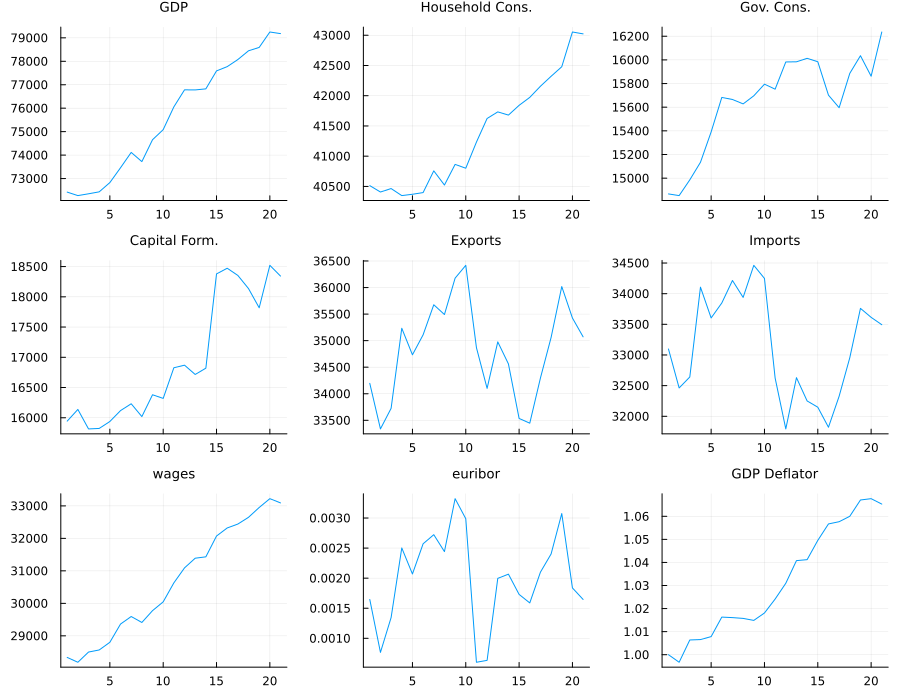

In [30]:
ps = Bit.plot_data(
        begin model end,
        quantities = [
            :real_gdp,
            :real_household_consumption,
            :real_government_consumption,
            :real_capitalformation,
            :real_exports,
            :real_imports,
            :wages,
            :euribor,
            :gdp_deflator,
        ],
    )
    plot(ps..., layout = (3, 3), size = (900, 700))

Cada passo equivale a 47 funções executadas sequencialmente. Verificamos então como as estatísticas agregadas da economia evolvem ao longo do tempo:
- Crescimento da ecônomia
- Inflação
- Desemprego

Observamos também que o modelo possui propriedades emergentes que também são verificadas na ecônomia, como:
- Oscilações econômicas
- Tendência de crescimento sustendada do PIB (países industrializados)


## 2. Regras autoregressivas de ordem 1 - AR(1)

As regras autoregressivas de ordem 1 são o cálculo de uma variável no futuro, $z_{t+1}$, a partir de uma relação linear da variável no passo de tempo anterior, ou seja:

$z_{t+1} = \alpha z_{t} + \beta$

Em Poledna et. al, essa regra é utilizada para:
- Formação das expectativas coletivas de crescimento dos PIB e inflação
- Modelagem de eventos exógenos com choques aleatórios (importações, exportações, gasto do governo, inflação e crescimento da área do euro)

Com relação às expectativas, a cada semestre os agentes calculam os parâmetros de maneira otimizada, ou seja, com o melhor fit possível com relação aos dados históricos. Na prática, os agentes estão aprendendo e atualizando suas expectativas, o que os torna `adaptativos`.

Abaixo vamos ilustrar como essa regra AR(1) é calculada na prática.

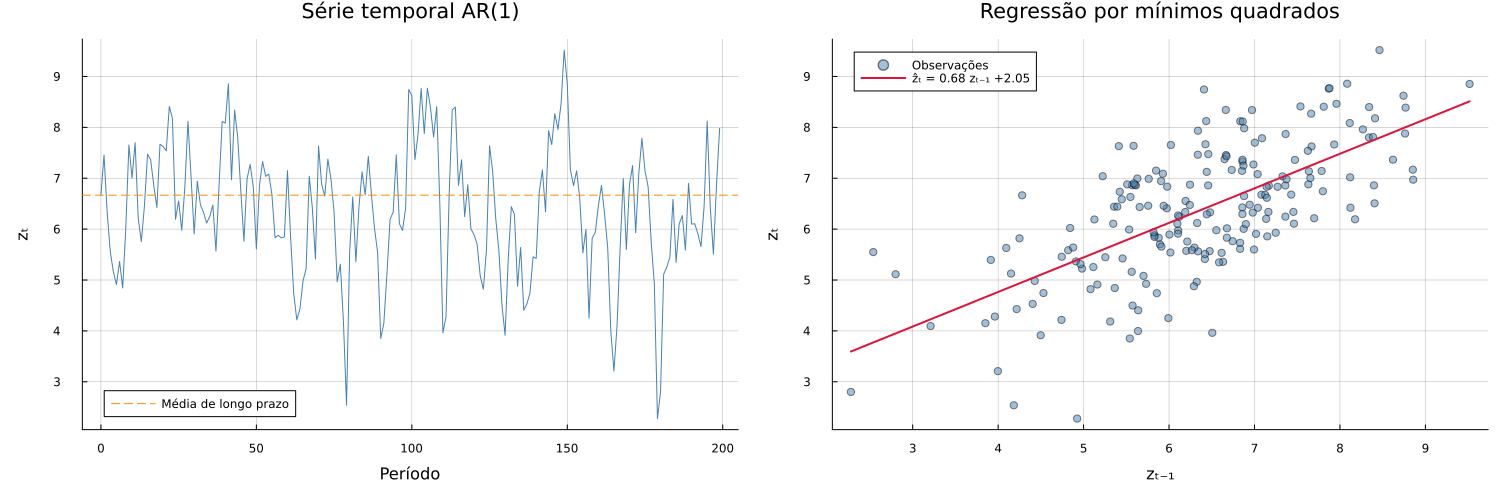

In [ ]:
using Printf

Random.seed!(42)

# Parameters used to generate the example
alpha_true = 0.7
beta_true = 2.0
n_observations = 200
long_run_mean = beta_true / (1 - alpha_true)

# Simulate a stationary AR(1) series
z = fill(long_run_mean, n_observations)

for t in 2:n_observations
    innovation = randn()
    z[t] = alpha_true * z[t-1] + beta_true + innovation
end

# Estimate the coefficients by least squares
lagged = z[1:end-1]
current = z[2:end]
design = hcat(lagged, ones(length(lagged)))
alpha_estimated, beta_estimated = design \ current
fitted = alpha_estimated .* lagged .+ beta_estimated

# 1. Time series
p1 = plot(
    0:(n_observations-1), z;
    color = :steelblue,
    title = "Série temporal AR(1)",
    xlabel = "Período",
    ylabel = "zₜ",
    label = false,
    gridalpha = 0.3,
)

hline!(
    p1,
    [long_run_mean];
    color = :darkorange,
    linestyle = :dash,
    label = "Média de longo prazo",
)

# 2. Least-squares regression
order = sortperm(lagged)

p2 = scatter(
    lagged, current;
    alpha = 0.5,
    color = :steelblue,
    label = "Observações",
    title = "Regressão por mínimos quadrados",
    xlabel = "zₜ₋₁",
    ylabel = "zₜ",
    gridalpha = 0.3,
)

plot!(
    p2,
    lagged[order],
    fitted[order];
    color = :crimson,
    linewidth = 2,
    label = @sprintf(
        "ẑₜ = %.2f zₜ₋₁ %+.2f",
        alpha_estimated,
        beta_estimated,
    ),
)

# 3. Sum of squared errors
alpha_values = range(
    alpha_estimated - 0.5,
    alpha_estimated + 0.5;
    length = 120,
)

beta_values = range(
    beta_estimated - 3,
    beta_estimated + 3;
    length = 120,
)

plot(
    p1, p2;
    layout = (1, 2),
    size = (1500, 500),
    left_margin = 10Plots.mm,
    bottom_margin = 10Plots.mm,
    top_margin = 5Plots.mm,
)



Em Poledna et. al, essa regra é utilizada de maneira otimizada para que os agentes possam construir suas expectativas em relação ao futuro econômico. Para isso, é feito um encaixe dos parâmetros $\alpha$ e $\beta$ para toda a série histórica da variável $z_{t}$ antes de aplicar a regra.

Esse procedimento é utilizado para calcular as `expectativas` das seguintes variáveis econômicas:
- Crescimento do PIB
- Inflação

O argumento principal é que esta é uma regra simples mas poderosa, onde os agentes ignoram as não linearidades que estão por trás das variáveis econômicas, e mesmo assim conseguem construir uma previsão conjunta da direção da econômia.  

Além disso, cada execução da regra é acompanhada por um choque exógeno proporcional ao quanto a regra autoregressva não consegue explicar da séria histórica da varíavel {TODO qual o nome?}. 

In [ ]:
# TODO código da regra autoregressiva

## 3. Calibração para as contas nacionais 

O trabalho busca se adequar das estatísticas calculadas pelos órgãos de contabilidade nacional. Nesse sentido, os parâmetros do modelo, que são muitos, em grande medida são retirados de diretamente dos relatórios destes órgãos ou calculados a partir deles, o que torna o modelo mais verossimilhante e reduz a necessidade de técnicas de estimação de parâmetros. 

Abaixo iremos explorar alguns dos parâmetros mais interessantes do modelo.

A matrix de `input-output`, concebida por Leontief, descreve as relações entre os diferentes setores produtivos. Cada linha representa o setor $s$ e cada coluna o produto $g$. A entrada da matriz representa o quanto do setor $s$ é utilizado para produzir o bem $g$.  

Outro ponto importante é a consistência estoque-fluxo do modelo. Isso quer dizer que não há um dinheiro ou recurso entrando de maneira "estranha" no modelo, ou seja, sabemos para cada transação, quem quem gastou, quem recebeu e como isso reflete nas contas de cada uma das partes. Na prática, isso fornece ao modelo a consistência contábil que é utilizada na mensuração dos indicadores macroeconomicos. 

In [ ]:
# TODO codigos da matrix input output e 

## 4. Mercados com fricção  ("Search and Matching")

Outra característica relevante do modelo é como os agentes econômicos, empresas, famílias e governos, se relacionam em mercados para produzir e consumir. 
 
Isto se dá através de mercados descentralizados, caracterizados pelo mecanismo de "search and matching", onde os consumidores são ordenados em ordem aleatória e as empresas são escolhidas com probabilidade proporcional ao seu tamanho e preço praticado. 

De acordo com os autores, este método permite reproduzir frições nas relações de troca e portanto mercados que não estão necessariamente em equilíbrio. Assim, é possível que consumidores não consigam comprar tudo que tinham em seu orçamento e é possível que empresas não consigam vender tudo aquilo que produziram. 

No entanto, caso não hajam mudanças abruptas no sistema, as empresas e consumidores tendem a caminhar em um percurso próximo ao equilíbrio onde a oferta se iguala ou está próxima do equilíbrio.      

In [ ]:
# TODO codigo search and matching 

## 5. Resultados

- Mensuração dos resultados (RMSE)

## 6. Críticas e alterações propostas  

- Sistema bancário
- "Autorealizável"

## TODOs

- Verificar quanto é um dinheiro na simulação
- Double check em empresas estrangeiras
- Double check na análise de valores (calibração)